# FinAgent Vaka Çalışması: Yüksek Enflasyon Ortamında Portföy Analizi

**Hazırlayan:** Melis CAN

**Tarih:** Eylül 2026  

**Veri Kaynakları:** TCMB EVDS API, Yahoo Finance  

**Analiz Dönemi:** Ocak 2020 - Eylül 2026

## 1. Kurulum ve Veri Bağlantısı

In [ ]:
from evds import evdsAPI
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import os
from datetime import date
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

api = evdsAPI(os.environ.get("TCMB_API_KEY", ""))
today = date.today().strftime("%d-%m-%Y")

## 2. EVDS'den Veri Çekme

In [2]:
def veri_cek(seri_kodu, isim, frekans=None):
    """EVDS'den tek bir seri çeker, temizler, döndürür."""
    kwargs = dict(series=[seri_kodu], startdate="01-01-2020", enddate=today)
    if frekans:
        kwargs["frequency"] = frekans
    df = api.get_data(**kwargs)

    tarih_col = [c for c in df.columns if "tarih" in c.lower() or "date" in c.lower()][0]
    df[tarih_col] = pd.to_datetime(df[tarih_col], format="mixed", dayfirst=True)
    df = df.sort_values(tarih_col).set_index(tarih_col)

    veri_sutunu = [c for c in df.columns if c != "UNIXTIME"][0]
    df = df[[veri_sutunu]].rename(columns={veri_sutunu: isim})
    df[isim] = pd.to_numeric(df[isim], errors="coerce")

    print(f"{isim}: {len(df)} satır ({df.index[0].date()} → {df.index[-1].date()})")
    return df

In [3]:
df_tufe  = veri_cek("TP.FG.J0", "TUFE_Endeks")
df_usd   = veri_cek("TP.DK.USD.A.YTL", "USD_TRY", frekans=5)
df_eur   = veri_cek("TP.DK.EUR.A.YTL", "EUR_TRY", frekans=5)
df_altin = veri_cek("TP.MK.KUL.YTL", "Altin_TL")

TUFE_Endeks: 73 satır (2020-01-01 → 2026-01-01)
USD_TRY: 81 satır (2020-01-01 → 2026-09-01)


EUR_TRY: 81 satır (2020-01-01 → 2026-09-01)


Altin_TL: 77 satır (2020-01-01 → 2026-05-01)


## 3. BIST 100 Verisi (Yahoo Finance)

In [4]:
bist = yf.download("XU100.IS", start="2020-01-01", progress=False)
df_bist = bist["Close"].copy()
df_bist.columns = ["BIST100"]
df_bist.index = pd.to_datetime(df_bist.index).tz_localize(None)
df_bist.index.name = "Tarih"

print(f"BIST 100: {len(df_bist)} satır ({df_bist.index[0].date()} → {df_bist.index[-1].date()})")
df_bist.tail()

BIST 100: 1684 satır (2020-01-02 → 2026-09-30)


,BIST100
Tarih,
2026-09-24,12888.299805
2026-09-25,12899.400391
2026-09-28,12592.799805
2026-09-29,12290.599609
2026-09-30,11947.179688


## 4. Enflasyon Hesaplama

In [5]:
df_tufe["TUFE_Yillik"] = df_tufe["TUFE_Endeks"].pct_change(periods=12) * 100

print("Son 5 ay enflasyon:")
print(df_tufe[["TUFE_Endeks", "TUFE_Yillik"]].tail())

Son 5 ay enflasyon:
            TUFE_Endeks  TUFE_Yillik
Tarih                               
2025-09-01      3367.22    33.294011
2025-10-01      3453.09    32.866856
2025-11-01      3482.96    31.074841
2025-12-01      3513.87    30.892328
2026-01-01      3683.83    30.648485


## 5. TCMB Politika Faizi

In [ ]:
import json
from pathlib import Path

_JSON_REL = Path("fin-agent-backend/app/core/data/policy_rate_history.json")
_json_path = next(
    (p for p in (_JSON_REL, Path("..") / _JSON_REL) if p.exists()),
    _JSON_REL,
)

with open(_json_path, encoding="utf-8") as f:
    faiz_verileri = json.load(f)

df_faiz = pd.DataFrame(
    list(faiz_verileri.items()),
    columns=["Tarih", "Politika_Faizi"]
)
df_faiz["Tarih"] = pd.to_datetime(df_faiz["Tarih"])
df_faiz = df_faiz.set_index("Tarih")

print(f"✓ Politika faizi: {len(df_faiz)} veri noktası (kaynak: {_json_path})")
df_faiz.tail()

✓ Politika faizi: 41 veri noktası (kaynak: fin-agent-backend/app/core/data/policy_rate_history.json)


,Politika_Faizi
Tarih,
2026-03-12,37.0
2026-04-22,37.0
2026-06-11,37.0
2026-07-23,37.0
2026-09-10,37.0


## 6. Verileri Birleştir ve Kaydet

In [7]:
df_all = pd.concat([df_tufe, df_usd, df_eur, df_altin, df_bist], axis=1, sort=False)
df_all = df_all.ffill()
df_all.to_csv("data/temel_veriler.csv")

print(f"Toplam: {len(df_all)} satır, {len(df_all.columns)} sütun")
df_all.tail()

Toplam: 1718 satır, 6 sütun


,TUFE_Endeks,TUFE_Yillik,USD_TRY,EUR_TRY,Altin_TL,BIST100
Tarih,,,,,,
2026-09-24,3683.83,30.648485,48.518664,55.91085,6741.91,12888.299805
2026-09-25,3683.83,30.648485,48.518664,55.91085,6741.91,12899.400391
2026-09-28,3683.83,30.648485,48.518664,55.91085,6741.91,12592.799805
2026-09-29,3683.83,30.648485,48.518664,55.91085,6741.91,12290.599609
2026-09-30,3683.83,30.648485,48.518664,55.91085,6741.91,11947.179688


---
## 7. Görselleştirmeler
### 7.1 Enflasyon Trendi

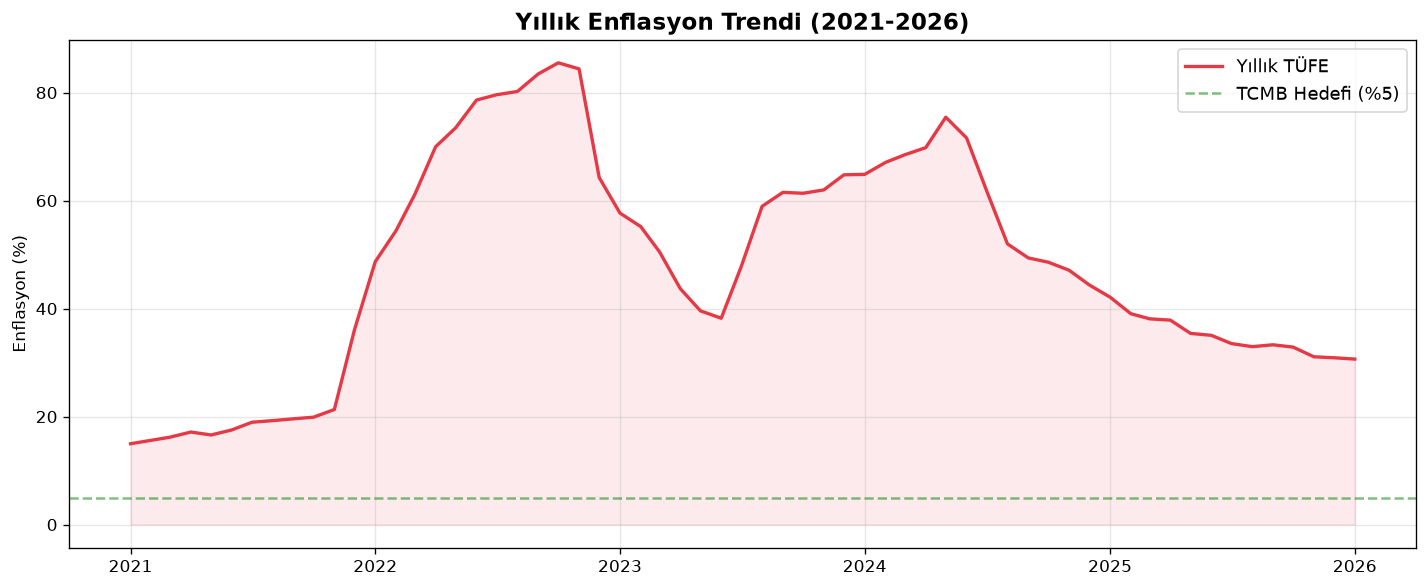

In [8]:
fig, ax = plt.subplots()

enf = df_tufe["TUFE_Yillik"].dropna()

ax.plot(enf.index, enf.values, color="#E63946", linewidth=2, label="Yıllık TÜFE")
ax.axhline(y=5, color="green", linestyle="--", alpha=0.5, label="TCMB Hedefi (%5)")
ax.fill_between(enf.index, enf.values, alpha=0.1, color="#E63946")

ax.set_title("Yıllık Enflasyon Trendi (2021-2026)", fontsize=14, fontweight="bold")
ax.set_ylabel("Enflasyon (%)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/enflasyon_trendi.png", bbox_inches="tight", dpi=150)
plt.show()

### 7.2 USD/TRY Kuru

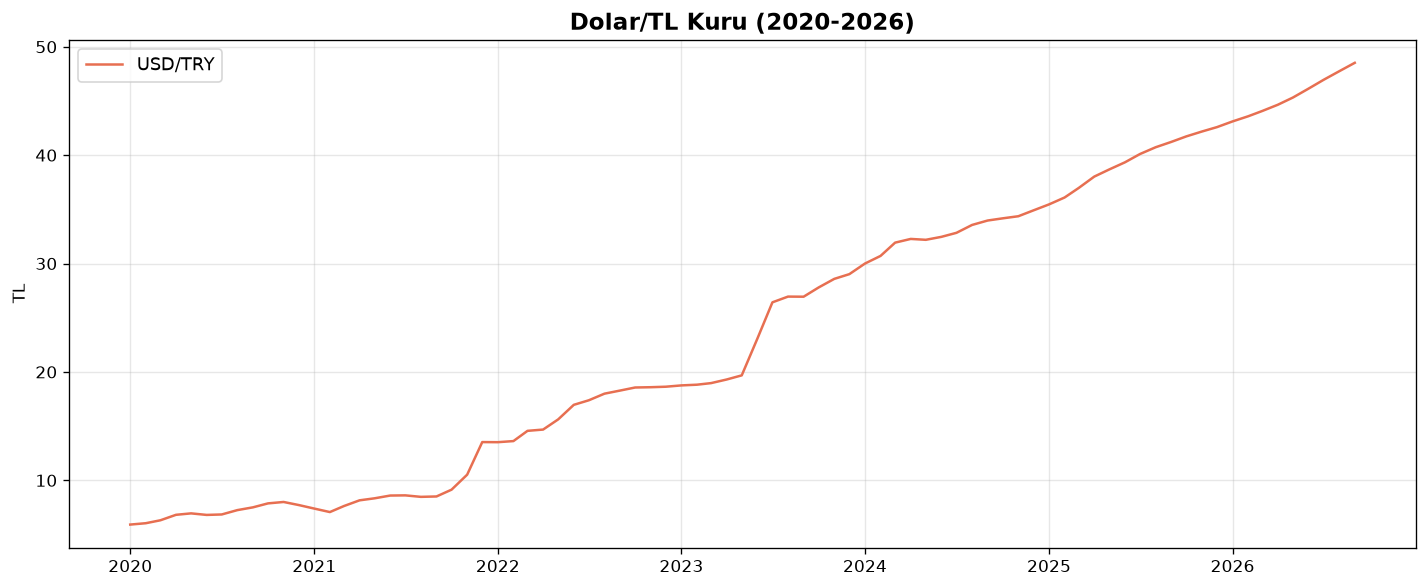

In [9]:
fig, ax = plt.subplots()

ax.plot(df_usd.index, df_usd["USD_TRY"], color="#E76F51", linewidth=1.5, label="USD/TRY")

ax.set_title("Dolar/TL Kuru (2020-2026)", fontsize=14, fontweight="bold")
ax.set_ylabel("TL")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/usd_try_kuru.png", bbox_inches="tight", dpi=150)
plt.show()

### 7.3 Gram Altın (TL)

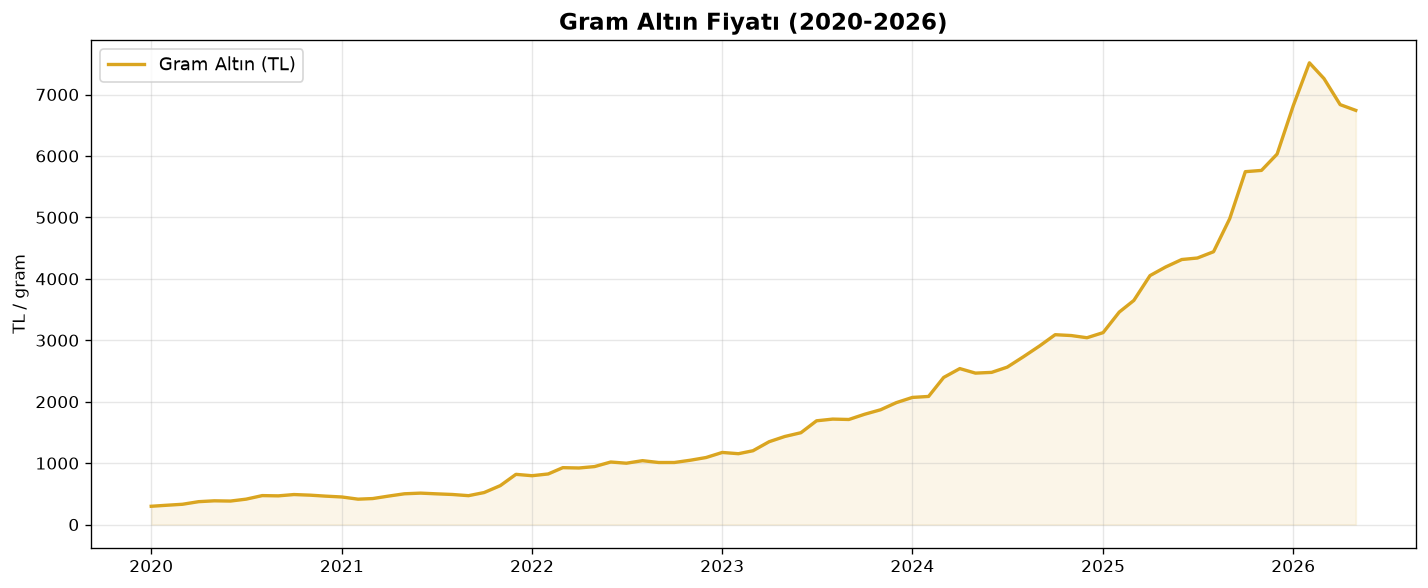

In [10]:
fig, ax = plt.subplots()

ax.plot(df_altin.index, df_altin["Altin_TL"], color="#DAA520", linewidth=2, label="Gram Altın (TL)")
ax.fill_between(df_altin.index, df_altin["Altin_TL"], alpha=0.1, color="#DAA520")

ax.set_title("Gram Altın Fiyatı (2020-2026)", fontsize=14, fontweight="bold")
ax.set_ylabel("TL / gram")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/altin_fiyati.png", bbox_inches="tight", dpi=150)
plt.show()

### 7.4 BIST 100 Endeksi

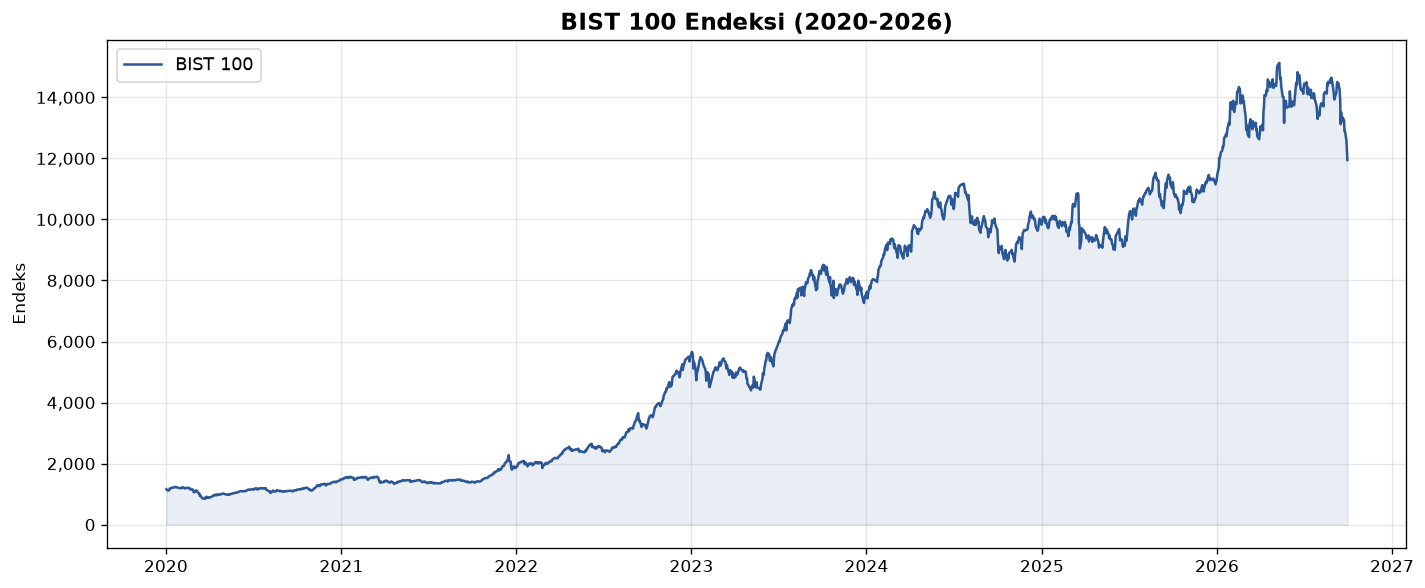

In [11]:
fig, ax = plt.subplots()

ax.plot(df_bist.index, df_bist["BIST100"], color="#2B5797", linewidth=1.5, label="BIST 100")
ax.fill_between(df_bist.index, df_bist["BIST100"].values.flatten(), alpha=0.1, color="#2B5797")

ax.set_title("BIST 100 Endeksi (2020-2026)", fontsize=14, fontweight="bold")
ax.set_ylabel("Endeks")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("outputs/bist100.png", bbox_inches="tight", dpi=150)
plt.show()

### 7.5 Enflasyon vs Politika Faizi

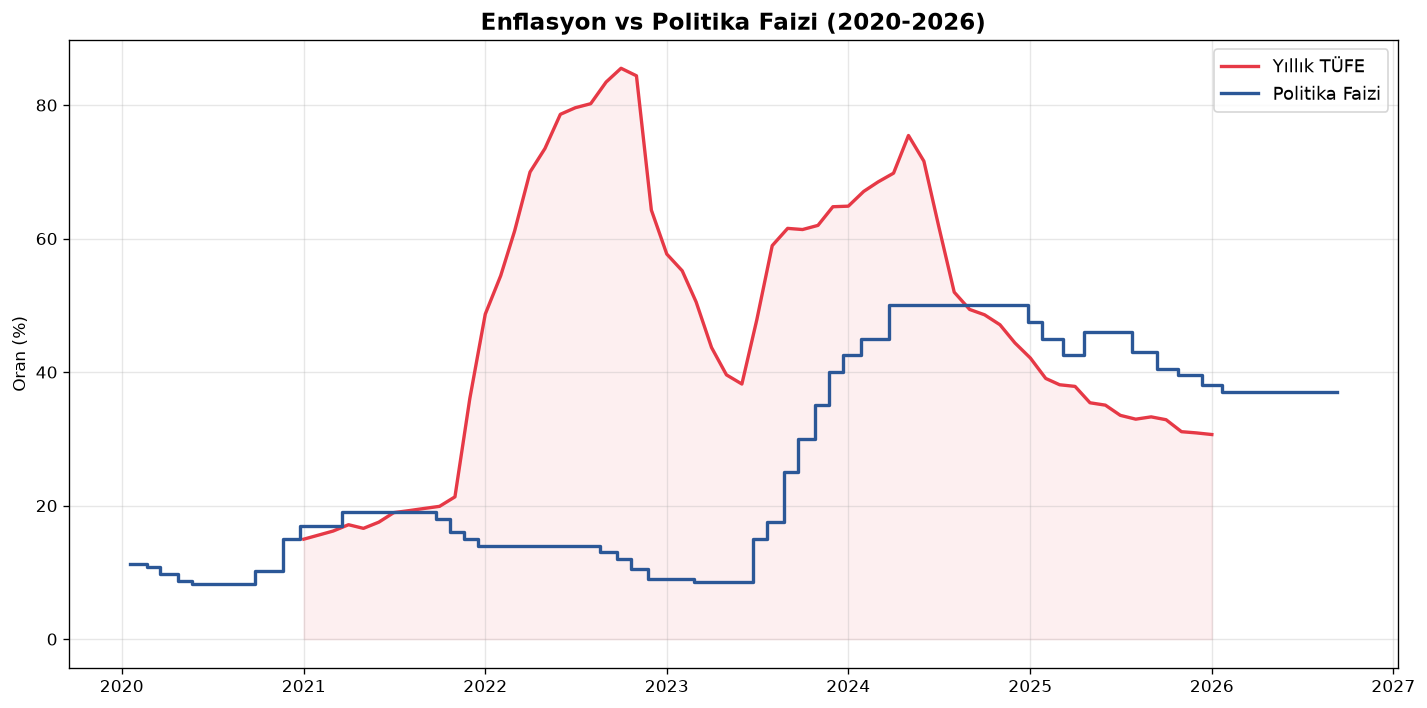

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

enf = df_tufe["TUFE_Yillik"].dropna()
ax.plot(enf.index, enf.values, color="#E63946", linewidth=2, label="Yıllık TÜFE")
ax.step(df_faiz.index, df_faiz["Politika_Faizi"], where="post",
        color="#2B5797", linewidth=2, label="Politika Faizi")

ax.fill_between(enf.index, enf.values, alpha=0.08, color="#E63946")

ax.set_title("Enflasyon vs Politika Faizi (2020-2026)", fontsize=14, fontweight="bold")
ax.set_ylabel("Oran (%)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/enflasyon_vs_faiz.png", bbox_inches="tight", dpi=150)
plt.show()

### 7.6 Normalize Performans Karşılaştırması (2020 = 100)

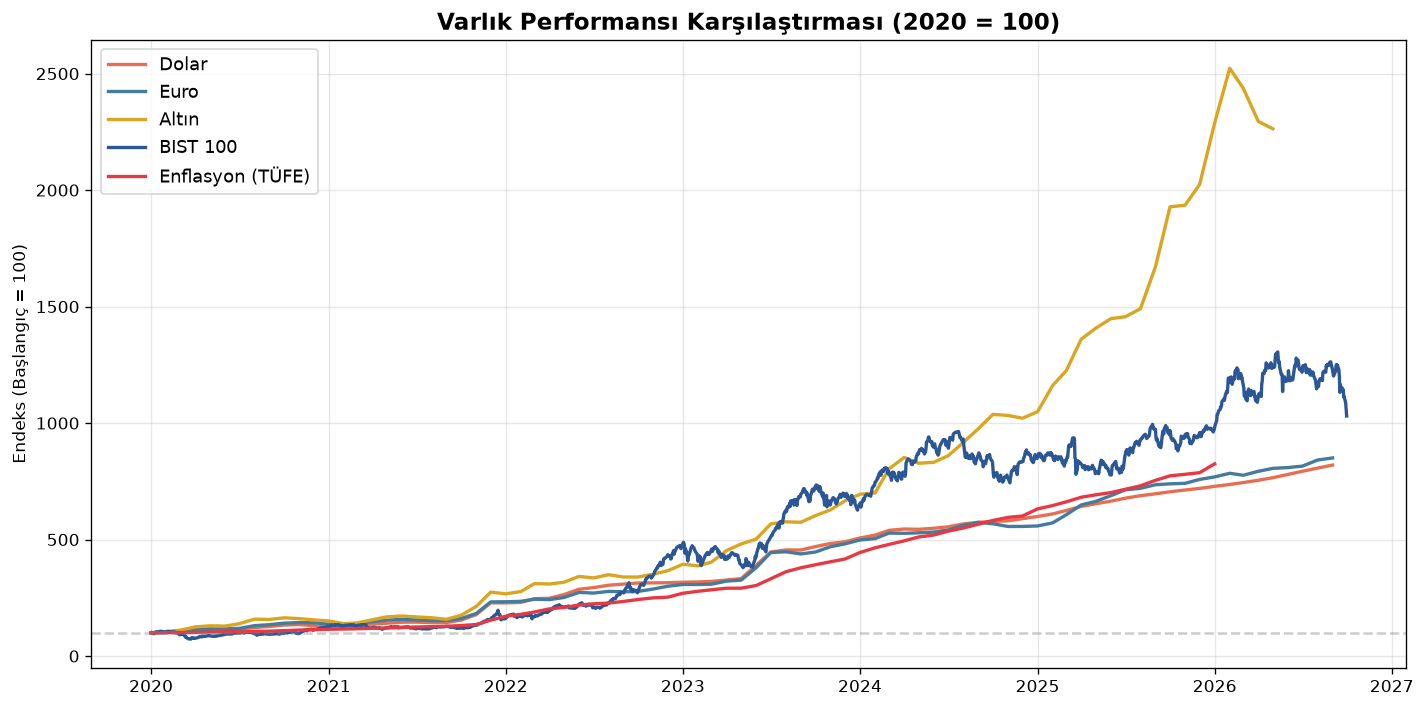

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

for df_temp, isim, renk in [
    (df_usd, "Dolar", "#E76F51"),
    (df_eur, "Euro", "#457B9D"),
    (df_altin, "Altın", "#DAA520"),
    (df_bist, "BIST 100", "#2B5797"),
    (df_tufe[["TUFE_Endeks"]], "Enflasyon (TÜFE)", "#E63946"),
]:
    sutun = df_temp.columns[0]
    seri = df_temp[sutun].dropna()
    normalize = (seri / seri.iloc[0]) * 100
    ax.plot(normalize.index, normalize.values, linewidth=2, label=isim, color=renk)

ax.axhline(y=100, color="gray", linestyle="--", alpha=0.4)

ax.set_title("Varlık Performansı Karşılaştırması (2020 = 100)", fontsize=14, fontweight="bold")
ax.set_ylabel("Endeks (Başlangıç = 100)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/normalize_performans.png", bbox_inches="tight", dpi=150)
plt.show()

---
## 8. Yatırım Simülasyonu
### 8.1 100.000 TL Geriye Dönük Test (Ocak 2023 - Bugün)

In [14]:
baslangic_tarih = "2023-01-01"
yatirim = 100_000

def getiri_hesapla(df, sutun, baslangic_tarih):
    """İlk ve son değere göre toplam getiriyi hesaplar."""
    df_filtre = df[sutun].dropna()
    df_filtre = df_filtre[df_filtre.index >= baslangic_tarih]
    ilk = df_filtre.iloc[0]
    son = df_filtre.iloc[-1]
    getiri = (son / ilk - 1) * 100
    deger = yatirim * (son / ilk)
    return ilk, son, getiri, deger

usd_ilk, usd_son, usd_getiri, usd_deger = getiri_hesapla(df_usd, "USD_TRY", baslangic_tarih)
eur_ilk, eur_son, eur_getiri, eur_deger = getiri_hesapla(df_eur, "EUR_TRY", baslangic_tarih)
alt_ilk, alt_son, alt_getiri, alt_deger = getiri_hesapla(df_altin, "Altin_TL", baslangic_tarih)
bist_ilk, bist_son, bist_getiri, bist_deger = getiri_hesapla(df_bist, "BIST100", baslangic_tarih)

tufe_filtre = df_tufe["TUFE_Endeks"].dropna()
tufe_filtre = tufe_filtre[tufe_filtre.index >= baslangic_tarih]
tufe_ilk = tufe_filtre.iloc[0]
tufe_son = tufe_filtre.iloc[-1]
nakit_reel = yatirim * (tufe_ilk / tufe_son)

mevduat_deger = yatirim * (1 + 0.35) ** 3
mevduat_getiri = (mevduat_deger / yatirim - 1) * 100

print("=" * 60)
print(f"  100.000 TL ile Yatırım Karşılaştırması (Ocak 2023)")
print("=" * 60)
print(f"  {'Araç':<20} {'Bugün (TL)':>12} {'Getiri':>10}")
print("-" * 60)
print(f"  {'Altın':<20} {alt_deger:>12,.0f} {alt_getiri:>9.1f}%")
print(f"  {'BIST 100':<20} {bist_deger:>12,.0f} {bist_getiri:>9.1f}%")
print(f"  {'Mevduat (ort.%35)':<20} {mevduat_deger:>12,.0f} {mevduat_getiri:>9.1f}%")
print(f"  {'Dolar':<20} {usd_deger:>12,.0f} {usd_getiri:>9.1f}%")
print(f"  {'Euro':<20} {eur_deger:>12,.0f} {eur_getiri:>9.1f}%")
print(f"  {'Nakit (yastık altı)':<20} {nakit_reel:>12,.0f}    eridi")
print("-" * 60)
print(f"  Nakit alım gücü kaybı: %{(1 - nakit_reel/yatirim)*100:.0f}")

  100.000 TL ile Yatırım Karşılaştırması (Ocak 2023)
  Araç                   Bugün (TL)     Getiri
------------------------------------------------------------
  Altın                     574,293     474.3%
  BIST 100                  211,041     111.0%
  Mevduat (ort.%35)         246,038     146.0%
  Dolar                     258,662     158.7%
  Euro                      276,845     176.8%
  Nakit (yastık altı)        32,669    eridi
------------------------------------------------------------
  Nakit alım gücü kaybı: %67


### 8.2 Simülasyon Grafiği

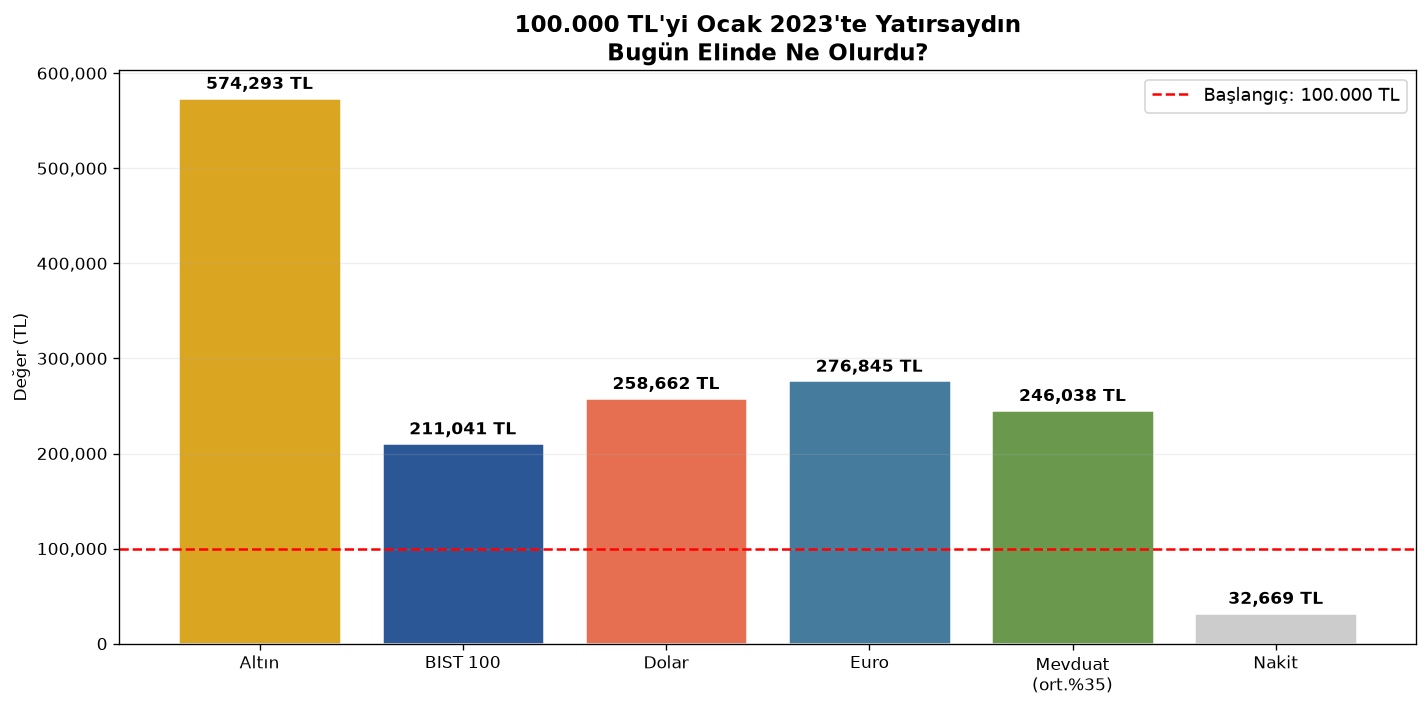

In [15]:
araclar = ["Altın", "BIST 100", "Dolar", "Euro", "Mevduat\n(ort.%35)", "Nakit"]
degerler = [alt_deger, bist_deger, usd_deger, eur_deger, mevduat_deger, nakit_reel]
renkler = ["#DAA520", "#2B5797", "#E76F51", "#457B9D", "#6A994E", "#CCCCCC"]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(araclar, degerler, color=renkler, edgecolor="white", linewidth=1.5)
ax.axhline(y=yatirim, color="red", linestyle="--", linewidth=1.5, label="Başlangıç: 100.000 TL")

for bar, deger in zip(bars, degerler):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f"{deger:,.0f} TL", ha="center", va="bottom", fontweight="bold", fontsize=10)

ax.set_title("100.000 TL'yi Ocak 2023'te Yatırsaydın\nBugün Elinde Ne Olurdu?",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Değer (TL)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2, axis="y")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("outputs/yatirim_simulasyonu.png", bbox_inches="tight", dpi=150)
plt.show()

---
## 9. Reel Getiri Analizi
Nominal getiri yanıltıcı olabilir. Asıl önemli olan enflasyon düzeltmesi sonrası **reel getiri**dir.

In [16]:
tufe_baslangic = df_tufe["TUFE_Endeks"].iloc[0]
tufe_son = df_tufe["TUFE_Endeks"].iloc[-1]
toplam_enflasyon = (tufe_son / tufe_baslangic - 1) * 100

baslangic_tarihi = df_usd.index[0]

usd_nominal = (df_usd.iloc[-1, 0] / df_usd.iloc[0, 0] - 1) * 100
eur_nominal = (df_eur.iloc[-1, 0] / df_eur.iloc[0, 0] - 1) * 100
altin_nominal = (df_altin.iloc[-1, 0] / df_altin.iloc[0, 0] - 1) * 100
bist_nominal = (df_bist.iloc[-1, 0] / df_bist.iloc[0, 0] - 1) * 100

gun_farki = (df_usd.index[-1] - baslangic_tarihi).days
yil_sayisi = gun_farki / 365.25
mevduat_nominal_r = ((1 + 0.35 * 0.825) ** yil_sayisi - 1) * 100

def reel_getiri(nominal_pct, enflasyon_pct):
    return ((1 + nominal_pct/100) / (1 + enflasyon_pct/100) - 1) * 100

varliklar = ["Altın", "BIST 100", "Dolar", "Euro", "Mevduat", "Nakit"]
nominal_getiriler = [altin_nominal, bist_nominal, usd_nominal, eur_nominal, mevduat_nominal_r, 0]
reel_getiriler = [reel_getiri(n, toplam_enflasyon) for n in nominal_getiriler]

print(f"Analiz Dönemi: {baslangic_tarihi.date()} → {df_usd.index[-1].date()}")
print(f"Dönemlik Toplam Enflasyon: %{toplam_enflasyon:.1f}")
print(f"\n{'Varlık':<12} {'Nominal':>10} {'Reel':>10}")
print("-" * 35)
for v, n, r in zip(varliklar, nominal_getiriler, reel_getiriler):
    print(f"{v:<12} {n:>9.1f}% {r:>9.1f}%")

Analiz Dönemi: 2020-01-01 → 2026-09-01
Dönemlik Toplam Enflasyon: %725.1

Varlık          Nominal       Reel
-----------------------------------
Altın           2163.1%     174.3%
BIST 100         930.5%      24.9%
Dolar            719.8%      -0.6%
Euro             750.3%       3.1%
Mevduat          442.6%     -34.2%
Nakit              0.0%     -87.9%


### 9.1 Nominal vs Reel Getiri Grafiği

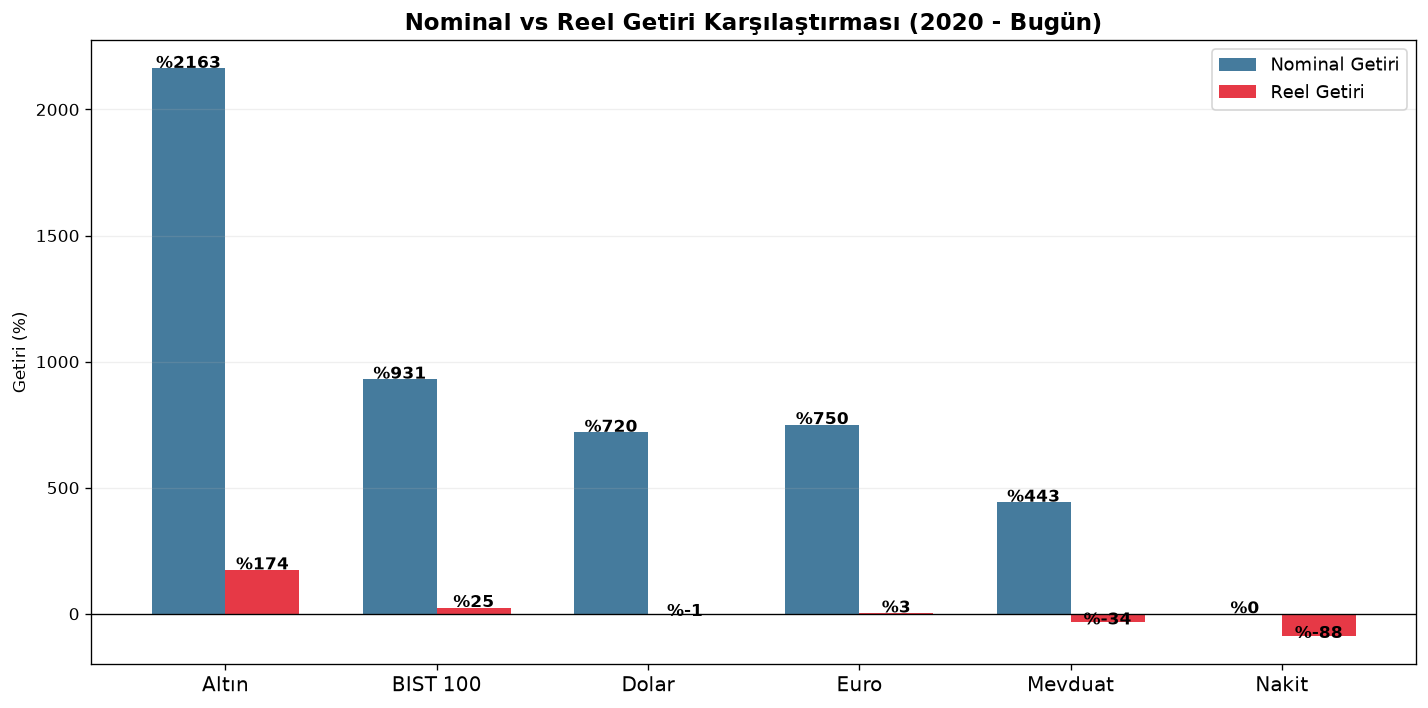

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(varliklar))
genislik = 0.35

bars_nominal = ax.bar(x - genislik/2, nominal_getiriler, genislik,
                       label="Nominal Getiri", color="#457B9D")
bars_reel = ax.bar(x + genislik/2, reel_getiriler, genislik,
                    label="Reel Getiri", color="#E63946")

ax.axhline(y=0, color="black", linewidth=0.8)

for bar, val in zip(bars_nominal, nominal_getiriler):
    y_pos = bar.get_height() + 2 if val >= 0 else bar.get_height() - 8
    ax.text(bar.get_x() + bar.get_width()/2, y_pos,
            f"%{val:.0f}", ha="center", fontsize=10, fontweight="bold")

for bar, val in zip(bars_reel, reel_getiriler):
    y_pos = bar.get_height() + 2 if val >= 0 else bar.get_height() - 8
    ax.text(bar.get_x() + bar.get_width()/2, y_pos,
            f"%{val:.0f}", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(varliklar, fontsize=12)
ax.set_ylabel("Getiri (%)")
ax.set_title("Nominal vs Reel Getiri Karşılaştırması (2020 - Bugün)",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig("outputs/reel_getiri.png", bbox_inches="tight", dpi=150)
plt.show()

---
## 10. Karar Matrisi
Her yatırım aracını 5 temel kriterde puanlayarak profil bazlı ağırlıklı skor üretiyoruz.

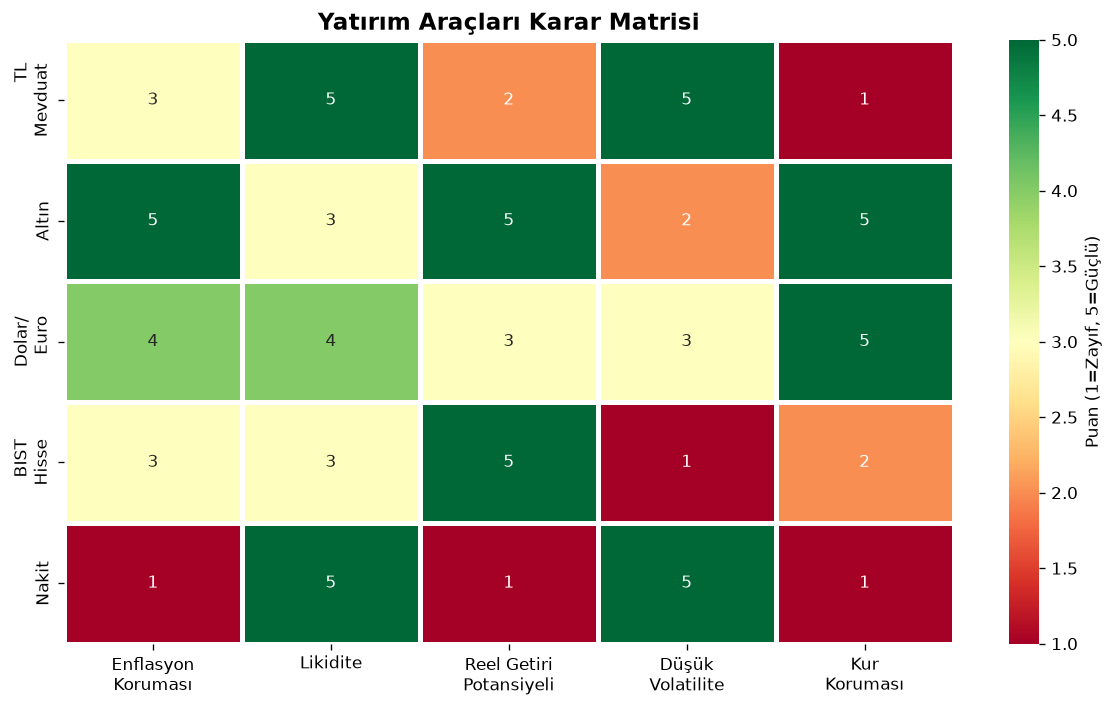


Profil Bazlı Ağırlıklı Skorlar:
Araç                Temkinli   Büyüme Odaklı
---------------------------------------------
TL Mevduat             3.55           2.90
Altın                  3.90           4.25
Döviz                  3.75           3.75
BIST Hisse             2.80           3.10
Nakit                  2.80           2.20


In [18]:
kriterler = ["Enflasyon\nKoruması", "Likidite", "Reel Getiri\nPotansiyeli",
             "Düşük\nVolatilite", "Kur\nKoruması"]
araclar_kisa = ["TL\nMevduat", "Altın", "Dolar/\nEuro", "BIST\nHisse", "Nakit"]

puanlar = np.array([
    [3, 5, 2, 5, 1],
    [5, 3, 5, 2, 5],
    [4, 4, 3, 3, 5],
    [3, 3, 5, 1, 2],
    [1, 5, 1, 5, 1],
])

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(puanlar, annot=True, fmt="d", cmap="RdYlGn",
            xticklabels=kriterler, yticklabels=araclar_kisa,
            linewidths=2, linecolor="white",
            cbar_kws={"label": "Puan (1=Zayıf, 5=Güçlü)"},
            vmin=1, vmax=5, ax=ax)

ax.set_title("Yatırım Araçları Karar Matrisi", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/karar_matrisi.png", bbox_inches="tight", dpi=150)
plt.show()

temkinli_agirlik = [0.30, 0.25, 0.15, 0.20, 0.10]
buyume_agirlik = [0.20, 0.15, 0.30, 0.15, 0.20]

print("\nProfil Bazlı Ağırlıklı Skorlar:")
print(f"{'Araç':<15} {'Temkinli':>12} {'Büyüme Odaklı':>15}")
print("-" * 45)
for i, arac in enumerate(["TL Mevduat", "Altın", "Döviz", "BIST Hisse", "Nakit"]):
    t_skor = sum(puanlar[i] * temkinli_agirlik)
    b_skor = sum(puanlar[i] * buyume_agirlik)
    print(f"{arac:<15} {t_skor:>11.2f} {b_skor:>14.2f}")

---
## 11. Portföy Dağılım Modelleri

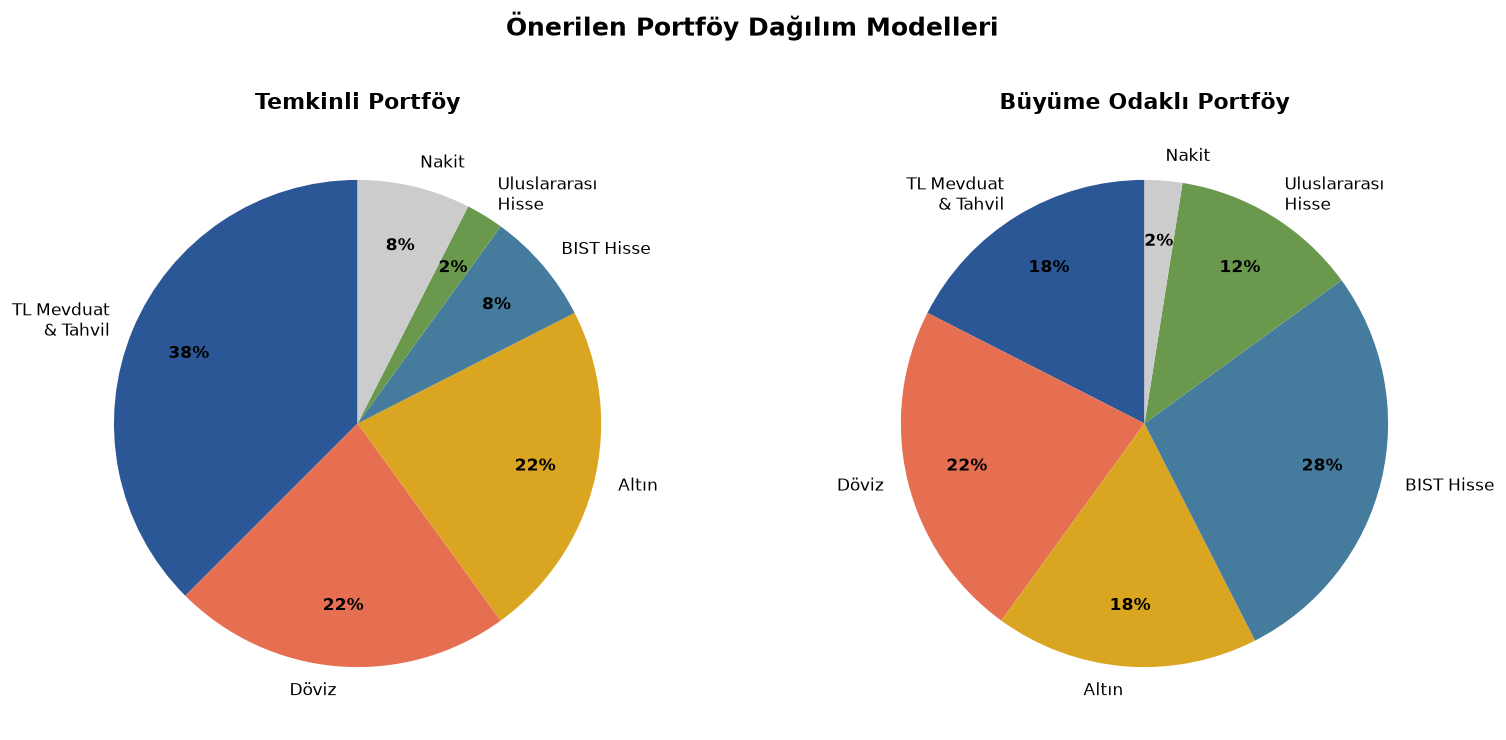

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

labels = ["TL Mevduat\n& Tahvil", "Döviz", "Altın", "BIST Hisse", "Uluslararası\nHisse", "Nakit"]
colors = ["#2B5797", "#E76F51", "#DAA520", "#457B9D", "#6A994E", "#CCCCCC"]

sizes_t = [37.5, 22.5, 22.5, 7.5, 2.5, 7.5]
wedges1, texts1, auto1 = ax1.pie(
    sizes_t, labels=labels, colors=colors, autopct="%1.0f%%",
    startangle=90, pctdistance=0.75, textprops={"fontsize": 10}
)
for t in auto1: t.set_fontweight("bold")
ax1.set_title("Temkinli Portföy", fontsize=13, fontweight="bold")

sizes_b = [17.5, 22.5, 17.5, 27.5, 12.5, 2.5]
wedges2, texts2, auto2 = ax2.pie(
    sizes_b, labels=labels, colors=colors, autopct="%1.0f%%",
    startangle=90, pctdistance=0.75, textprops={"fontsize": 10}
)
for t in auto2: t.set_fontweight("bold")
ax2.set_title("Büyüme Odaklı Portföy", fontsize=13, fontweight="bold")

fig.suptitle("Önerilen Portföy Dağılım Modelleri", fontsize=15, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("outputs/portfoy_dagilimi.png", bbox_inches="tight", dpi=150)
plt.show()

---
## 12. Monte Carlo Simülasyonu
1.000 rastgele senaryo üreterek temkinli portföyün 3 yıllık olası sonuçlarını modelliyoruz.

In [20]:
np.random.seed(42)
n_sim = 1000
n_ay = 36
baslangic_mc = 100_000

agirliklar = {
    "mevduat": 0.35, "altin": 0.25, "doviz": 0.20,
    "bist": 0.10, "nakit": 0.10
}

params = {
    "mevduat": {"ort": 0.025, "std": 0.003},
    "altin":   {"ort": 0.028, "std": 0.065},
    "doviz":   {"ort": 0.013, "std": 0.035},
    "bist":    {"ort": 0.018, "std": 0.085},
    "nakit":   {"ort": -0.020, "std": 0.005}
}

sonuclar = np.zeros(n_sim)

for i in range(n_sim):
    portfoy = baslangic_mc
    for ay in range(n_ay):
        aylik_getiri = sum(
            agirlik * np.random.normal(params[varlik]["ort"], params[varlik]["std"])
            for varlik, agirlik in agirliklar.items()
        )
        portfoy *= (1 + aylik_getiri)
    sonuclar[i] = portfoy

enflasyon_3yil = (1.25) ** 3
reel_sonuclar = sonuclar / enflasyon_3yil

print("MONTE CARLO SİMÜLASYONU — Temkinli Portföy")
print(f"Başlangıç: {baslangic_mc:,.0f} TL | Süre: 3 yıl | Simülasyon: {n_sim}")
print(f"\n{'Metrik':<25} {'Nominal':>15} {'Reel':>15}")
print("-" * 57)
print(f"{'Medyan (P50)':<25} {np.median(sonuclar):>14,.0f} {np.median(reel_sonuclar):>14,.0f}")
print(f"{'Ortalama':<25} {np.mean(sonuclar):>14,.0f} {np.mean(reel_sonuclar):>14,.0f}")
print(f"{'En kötü %5 (P5)':<25} {np.percentile(sonuclar, 5):>14,.0f} {np.percentile(reel_sonuclar, 5):>14,.0f}")
print(f"{'En iyi %5 (P95)':<25} {np.percentile(sonuclar, 95):>14,.0f} {np.percentile(reel_sonuclar, 95):>14,.0f}")
print(f"\nSermaye kaybı olasılığı (nominal): %{(sonuclar < baslangic_mc).mean()*100:.1f}")
print(f"Reel sermaye kaybı olasılığı: %{(reel_sonuclar < baslangic_mc).mean()*100:.1f}")

MONTE CARLO SİMÜLASYONU — Temkinli Portföy
Başlangıç: 100,000 TL | Süre: 3 yıl | Simülasyon: 1000

Metrik                            Nominal            Reel
---------------------------------------------------------


Medyan (P50)                     190,856         97,718
Ortalama                         192,128         98,370
En kötü %5 (P5)                  158,829         81,320
En iyi %5 (P95)                  229,911        117,714

Sermaye kaybı olasılığı (nominal): %0.0
Reel sermaye kaybı olasılığı: %58.7


### 12.1 Monte Carlo Görselleri

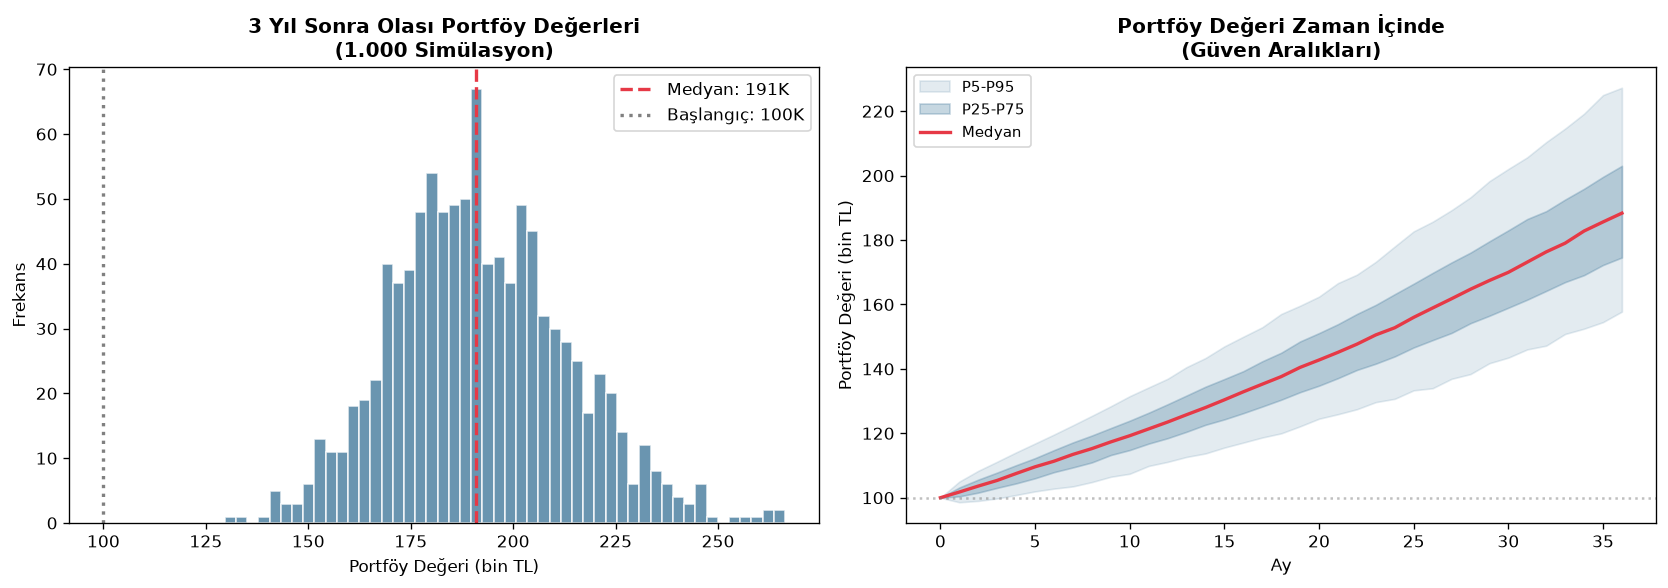

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(sonuclar / 1000, bins=50, color="#457B9D", edgecolor="white", alpha=0.8)
ax1.axvline(np.median(sonuclar)/1000, color="#E63946", linestyle="--",
            linewidth=2, label=f"Medyan: {np.median(sonuclar)/1000:,.0f}K")
ax1.axvline(baslangic_mc/1000, color="gray", linestyle=":",
            linewidth=2, label=f"Başlangıç: {baslangic_mc/1000:.0f}K")
ax1.set_xlabel("Portföy Değeri (bin TL)")
ax1.set_ylabel("Frekans")
ax1.set_title("3 Yıl Sonra Olası Portföy Değerleri\n(1.000 Simülasyon)", fontweight="bold")
ax1.legend()

aylik_seriler = np.zeros((n_sim, n_ay + 1))
aylik_seriler[:, 0] = baslangic_mc

for i in range(n_sim):
    portfoy = baslangic_mc
    for ay in range(n_ay):
        aylik_getiri = sum(
            agirlik * np.random.normal(params[varlik]["ort"], params[varlik]["std"])
            for varlik, agirlik in agirliklar.items()
        )
        portfoy *= (1 + aylik_getiri)
        aylik_seriler[i, ay + 1] = portfoy

aylar = np.arange(n_ay + 1)
p5  = np.percentile(aylik_seriler, 5, axis=0) / 1000
p25 = np.percentile(aylik_seriler, 25, axis=0) / 1000
p50 = np.percentile(aylik_seriler, 50, axis=0) / 1000
p75 = np.percentile(aylik_seriler, 75, axis=0) / 1000
p95 = np.percentile(aylik_seriler, 95, axis=0) / 1000

ax2.fill_between(aylar, p5, p95, alpha=0.15, color="#457B9D", label="P5-P95")
ax2.fill_between(aylar, p25, p75, alpha=0.3, color="#457B9D", label="P25-P75")
ax2.plot(aylar, p50, color="#E63946", linewidth=2, label="Medyan")
ax2.axhline(y=baslangic_mc/1000, color="gray", linestyle=":", alpha=0.5)

ax2.set_xlabel("Ay")
ax2.set_ylabel("Portföy Değeri (bin TL)")
ax2.set_title("Portföy Değeri Zaman İçinde\n(Güven Aralıkları)", fontweight="bold")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("outputs/monte_carlo.png", bbox_inches="tight", dpi=150)
plt.show()

---
## 13. Temel Bulgular

1. **Enflasyon her şeyin üzerinde:** Nakit tutan kişi 3 yılda alım gücünün yaklaşık 2/3'ünü kaybetti.
2. **Altın açık ara kazanan:** Hem nominal hem reel bazda en yüksek getiriyi sağladı.
3. **Döviz, enflasyonu yenemedi:** Dolar ve euro nominal artışa rağmen reel olarak negatif getiri verdi.
4. **Çeşitlendirme zorunlu:** Monte Carlo simülasyonu gösteriyor ki tek bir varlığa yoğunlaşmak yerine dengeli dağılım riski azaltıyor.
5. **Karar matrisi profil bazlı düşünmeyi zorunlu kılıyor:** Temkinli ve büyüme odaklı yatırımcı aynı araçlara farklı ağırlıklar vermeli.